In [ ]:
import torch
from torch.nn.utils import spectral_norm
import torch.nn as nn

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [-1, 1]
])

dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(dataset, batch_size=128, shuffle=True)

In [ ]:
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, z_dim=100, num_classes=10):
        super().__init__()

        self.label_emb = nn.Embedding(num_classes, num_classes)

        self.fc = nn.Linear(z_dim + num_classes, 256 * 4 * 4)

        self.net = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 1, 0),  # 4→7
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 7→14
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 1, 4, 2, 1),     # 14→28
            nn.Tanh()
        )

    def forward(self, z, labels):
        c = self.label_emb(labels)
        x = torch.cat([z, c], dim=1)
        x = self.fc(x).view(-1, 256, 4, 4)
        return self.net(x)

In [ ]:
import torch
import torch.nn as nn
from torch.nn.utils import spectral_norm

class Discriminator(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.label_emb = nn.Embedding(num_classes, num_classes)

        self.embed_proj = nn.Linear(num_classes, 28 * 28)

        self.net = nn.Sequential(
            spectral_norm(nn.Conv2d(2, 64, 4, 2, 1)),   # → (64, 14, 14)
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(64, 128, 4, 2, 1)), # → (128, 7, 7)
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(128, 256, 3, 2, 1)),# → (256, 4, 4)
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(256, 1, 4, 1, 0)),  # → (1, 1, 1)

        )

    def forward(self, img, labels):
        batch_size = img.size(0)

        c = self.label_emb(labels)

        c = self.embed_proj(c)                  # (batch, 28*28)
        c = c.view(batch_size, 1, 28, 28)       # (batch, 1, 28, 28)

        x = torch.cat([img, c], dim=1)          # (batch, 2, 28, 28)

        return self.net(x).view(-1, 1)

#Task 2

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define device to use GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCEWithLogitsLoss()

opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

In [ ]:
def smooth_real_labels(size):
    return torch.empty(size, 1).uniform_(0.9, 1.0).to(device)

def fake_labels(size):
    return torch.zeros(size, 1).to(device)

In [ ]:
import os
fixed_z = torch.randn(100, 100).to(device)
fixed_labels = torch.tensor([i for i in range(10) for _ in range(10)]).to(device)

os.makedirs("samples", exist_ok=True)

In [ ]:
g_losses = []
d_losses = []

In [ ]:
import torchvision.utils as vutils

epochs = 100

for epoch in range(epochs):
    for real_imgs, labels in loader:

        real_imgs = real_imgs.to(device)
        labels = labels.to(device)
        batch_size = real_imgs.size(0)

        # ---------------------
        # Train Discriminator
        # ---------------------
        z = torch.randn(batch_size, 100).to(device)
        fake_imgs = G(z, labels)

        real_target = smooth_real_labels(batch_size)
        fake_target = fake_labels(batch_size)

        loss_real = criterion(D(real_imgs, labels), real_target)
        loss_fake = criterion(D(fake_imgs.detach(), labels), fake_target)
        loss_D = loss_real + loss_fake

        if loss_D.item() > 0.3:
            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

        # ---------------------
        # Train Generator
        # ---------------------
        z = torch.randn(batch_size, 100).to(device)
        fake_imgs = G(z, labels)

        target = torch.ones(batch_size, 1).to(device)

        loss_G = criterion(D(fake_imgs, labels), target)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(f"Epoch [{epoch}/{epochs}]  Loss D: {loss_D.item():.4f}, Loss G: {loss_G.item():.4f}")
    g_losses.append(loss_G.item())
    d_losses.append(loss_D.item())

    # ---------------------
    # Save images
    # ---------------------
    if epoch % 5 == 0:
        with torch.no_grad():
            fake = G(fixed_z, fixed_labels)

            vutils.save_image(
                fake,
                f"samples/epoch_{epoch}.png",
                nrow=10,
                normalize=True
            )

    # ---------------------
    # Save Generator model for FID calculation
    # ---------------------
    if epoch in [9, 49, 99]: # Epochs 10, 50, 100 (0-indexed)
        torch.save(G.state_dict(), f"generator_epoch_{epoch + 1}.pth")

Epoch [0/100]  Loss D: 1.2907, Loss G: 0.8920
Epoch [1/100]  Loss D: 1.2814, Loss G: 0.9237
Epoch [2/100]  Loss D: 1.2490, Loss G: 0.9776
Epoch [3/100]  Loss D: 1.3171, Loss G: 0.8145
Epoch [4/100]  Loss D: 1.3051, Loss G: 0.7950
Epoch [5/100]  Loss D: 1.3248, Loss G: 0.8123
Epoch [6/100]  Loss D: 1.3443, Loss G: 0.7723
Epoch [7/100]  Loss D: 1.3374, Loss G: 0.8540
Epoch [8/100]  Loss D: 1.3289, Loss G: 0.7123
Epoch [9/100]  Loss D: 1.3445, Loss G: 0.7646
Epoch [10/100]  Loss D: 1.3260, Loss G: 0.8300
Epoch [11/100]  Loss D: 1.3174, Loss G: 0.7881
Epoch [12/100]  Loss D: 1.3365, Loss G: 0.8071
Epoch [13/100]  Loss D: 1.3621, Loss G: 0.7738
Epoch [14/100]  Loss D: 1.3724, Loss G: 0.7659
Epoch [15/100]  Loss D: 1.3409, Loss G: 0.8031
Epoch [16/100]  Loss D: 1.3722, Loss G: 0.8231
Epoch [17/100]  Loss D: 1.3470, Loss G: 0.7590
Epoch [18/100]  Loss D: 1.3475, Loss G: 0.8214
Epoch [19/100]  Loss D: 1.3435, Loss G: 0.7965
Epoch [20/100]  Loss D: 1.3552, Loss G: 0.8137
Epoch [21/100]  Loss D:

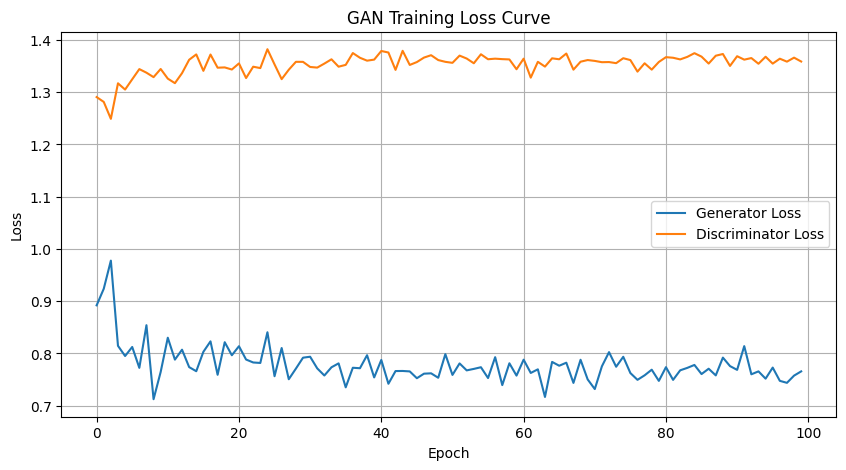

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss Curve")
plt.legend()

plt.grid(True)
plt.show()

### Visual Inspection of Generated Images

Let's load and display some of the generated images from different epochs to visually check for signs of mode collapse (e.g., lack of diversity, repetition).

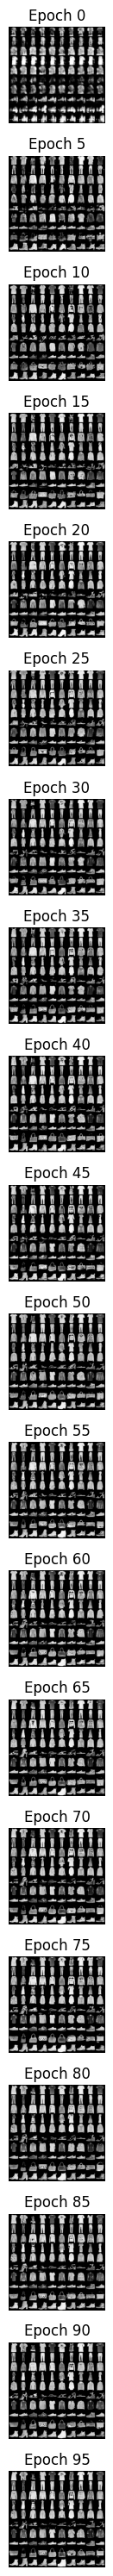

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# List of epochs for which images were saved
saved_epochs = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95]

plt.figure(figsize=(15, len(saved_epochs) * 1.5))

for i, epoch in enumerate(saved_epochs):
    img_path = f"samples/epoch_{epoch}.png"
    if os.path.exists(img_path):
        ax = plt.subplot(len(saved_epochs), 1, i + 1)
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.set_title(f'Epoch {epoch}')
        ax.axis('off')
    else:
        print(f"Image for epoch {epoch} not found at {img_path}")

plt.tight_layout()
plt.show()

In [ ]:
# Install the pytorch-fid library
!pip install pytorch-fid

In [ ]:
import numpy as np
from PIL import Image
import os
import math
import shutil # For removing directories
import torchvision.transforms as transforms

# --- Helper function to save images for FID calculation ---
def save_images_for_fid(model_or_data, num_images, output_dir, device, num_classes=10, is_real=False, image_size=28):
    os.makedirs(output_dir, exist_ok=True)

    if is_real:
        # For real images from a DataLoader
        current_images_saved = {i: 0 for i in range(num_classes)}
        images_per_class_target = num_images // num_classes

        # Iterate through the actual DataLoader
        for imgs, labels in model_or_data:
            imgs = imgs.to(device) # Move to device if not already
            labels = labels.to(device)

            for i in range(imgs.size(0)): # Iterate through batch
                label = labels[i].item()
                if current_images_saved[label] < images_per_class_target:
                    img_tensor = imgs[i] # Shape (1, H, W)

                    # Denormalize from [-1, 1] to [0, 255] and convert to uint8
                    img_np = (img_tensor * 0.5 + 0.5).mul(255).add(0.5).clamp(0, 255).to(torch.uint8).cpu().numpy()
                    img_np = np.squeeze(img_np) # Shape (H, W) for grayscale PIL

                    # FID expects 3 channels. Convert grayscale to RGB.
                    # PIL's 'RGB' mode from 'L' automatically duplicates channels.
                    Image.fromarray(img_np, 'L').convert('RGB').save(os.path.join(output_dir, f"{label}_{current_images_saved[label]}.png"))
                    current_images_saved[label] += 1

            if sum(current_images_saved.values()) >= num_images:
                break
        print(f"Saved {sum(current_images_saved.values())} real images to {output_dir}")
    else:
        # For fake images from a Generator
        model = model_or_data # This is the Generator
        model.eval()
        with torch.no_grad():
            # Generate labels for all images first (1000 per class)
            all_labels = torch.tensor([i for i in range(num_classes) for _ in range(num_images // num_classes)], device=device)
            all_z = torch.randn(num_images, 100, device=device)

            batch_size_gen = 128 # Generate in batches
            num_batches = math.ceil(num_images / batch_size_gen)

            count = 0
            for i in range(num_batches):
                start_idx = i * batch_size_gen
                end_idx = min((i + 1) * batch_size_gen, num_images)

                batch_z = all_z[start_idx:end_idx]
                batch_labels = all_labels[start_idx:end_idx]

                fake_imgs = model(batch_z, batch_labels) # Shape (batch, 1, H, W)

                for j in range(fake_imgs.size(0)): # Iterate through batch
                    img_tensor = fake_imgs[j] # Shape (1, H, W)

                    # Denormalize from [-1, 1] to [0, 255] and convert to uint8
                    img_np = (img_tensor * 0.5 + 0.5).mul(255).add(0.5).clamp(0, 255).to(torch.uint8).cpu().numpy()
                    img_np = np.squeeze(img_np) # Shape (H, W)

                    # FID expects 3 channels. Convert grayscale to RGB.
                    Image.fromarray(img_np, 'L').convert('RGB').save(os.path.join(output_dir, f"{batch_labels[j].item()}_{count}.png"))
                    count += 1
        print(f"Saved {count} fake images to {output_dir}")

### Prepare Real Images for FID Calculation

We will save 10,000 real FashionMNIST images (1,000 per class) to a directory, denormalized and converted to RGB, for comparison with generated images.

In [ ]:
# Create a separate DataLoader for real images to ensure we can iterate through it easily for FID
# We'll re-initialize the dataset without the transforms, as we'll handle normalization/denormalization manually

# Define a simple ToTensor transform for loading, we'll manually handle denormalization
raw_transform = transforms.ToTensor()

real_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=raw_transform # Use a basic ToTensor, we denormalize later
)
real_loader_fid = DataLoader(real_dataset, batch_size=128, shuffle=True)

# Directory for real images
real_images_path = "fid_data/real_images"

# Clean up previous directory if exists
if os.path.exists(real_images_path):
    shutil.rmtree(real_images_path)

print("Saving real images...")
save_images_for_fid(real_loader_fid, num_images=10000, output_dir=real_images_path, device=device, is_real=True)
print("Real images saved.")

Saving real images...


/tmp/ipykernel_8355/1747304446.py:33: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(img_np, 'L').convert('RGB').save(os.path.join(output_dir, f"{label}_{current_images_saved[label]}.png"))


Saved 10000 real images to fid_data/real_images
Real images saved.


### Calculate FID Scores

Now we will load the saved Generator models at epochs 10, 50, and 100, generate 10,000 images for each, and compute the FID against the real FashionMNIST dataset.

In [ ]:
from pytorch_fid import fid_score

fid_epochs = [10, 50, 100]
results_fid = {}

for epoch in fid_epochs:
    print(f"\n--- Calculating FID for Epoch {epoch} ---")

    # Load the generator for the current epoch
    generator_state_path = f"generator_epoch_{epoch}.pth"
    if not os.path.exists(generator_state_path):
        print(f"Warning: Generator state for epoch {epoch} not found at {generator_state_path}. Skipping.")
        continue

    G_fid = Generator().to(device) # Create a new Generator instance
    G_fid.load_state_dict(torch.load(generator_state_path, map_location=device))
    G_fid.eval() # Set to evaluation mode

    # Create directory for fake images for this epoch
    fake_images_path = f"fid_data/fake_images_epoch_{epoch}"
    if os.path.exists(fake_images_path): # Clean up if it exists
        shutil.rmtree(fake_images_path)

    print(f"Generating fake images for epoch {epoch}...")
    save_images_for_fid(G_fid, num_images=10000, output_dir=fake_images_path, device=device, is_real=False)
    print(f"Fake images for epoch {epoch} generated.")

    # Calculate FID score
    # The FID calculation requires the path to the real images and the path to the generated images
    # The FID implementation expects 3-channel images, so our helper converts 'L' to 'RGB'
    fid_value = fid_score.calculate_fid_given_paths(
        [real_images_path, fake_images_path], # Paths to image directories
        batch_size=128, # Batch size for inception model
        device=device,  # Device to run inception model on
        dims=2048       # Dimensions of Inception features
    )

    print(f"FID Score for Epoch {epoch}: {fid_value:.2f}")
    results_fid[epoch] = fid_value

    # Clean up generated images for this epoch
    shutil.rmtree(fake_images_path)

print("\n--- FID Calculation Complete ---")
print("FID Scores:", results_fid)

# Report best FID
if results_fid:
    best_epoch = min(results_fid, key=results_fid.get)
    print(f"Best FID score: {results_fid[best_epoch]:.2f} at Epoch {best_epoch}")
else:
    print("No FID scores calculated.")


--- Calculating FID for Epoch 10 ---
Generating fake images for epoch 10...


/tmp/ipykernel_8355/1747304446.py:69: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(img_np, 'L').convert('RGB').save(os.path.join(output_dir, f"{batch_labels[j].item()}_{count}.png"))


Saved 10000 fake images to fid_data/fake_images_epoch_10
Fake images for epoch 10 generated.
Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth


100%|██████████| 91.2M/91.2M [00:01<00:00, 76.9MB/s]
100%|██████████| 79/79 [00:37<00:00,  2.08it/s]


FID Score for Epoch 10: 92.32

--- Calculating FID for Epoch 50 ---
Generating fake images for epoch 50...
Saved 10000 fake images to fid_data/fake_images_epoch_50
Fake images for epoch 50 generated.


100%|██████████| 79/79 [00:37<00:00,  2.08it/s]


FID Score for Epoch 50: 31.54

--- Calculating FID for Epoch 100 ---
Generating fake images for epoch 100...
Saved 10000 fake images to fid_data/fake_images_epoch_100
Fake images for epoch 100 generated.


100%|██████████| 79/79 [00:37<00:00,  2.08it/s]


FID Score for Epoch 100: 25.45

--- FID Calculation Complete ---
FID Scores: {10: np.float64(92.32117996109781), 50: np.float64(31.53665585642159), 100: np.float64(25.454781228921206)}
Best FID score: 25.45 at Epoch 100


### Spherical Linear Interpolation (Slerp)

We will perform spherical linear interpolation (slerp) between two random noise vectors `z1` and `z2`, holding the class label fixed. This will generate a sequence of 10 interpolated images, showing a smooth transition. We will repeat this process for 3 different class labels to observe the effect across different categories.

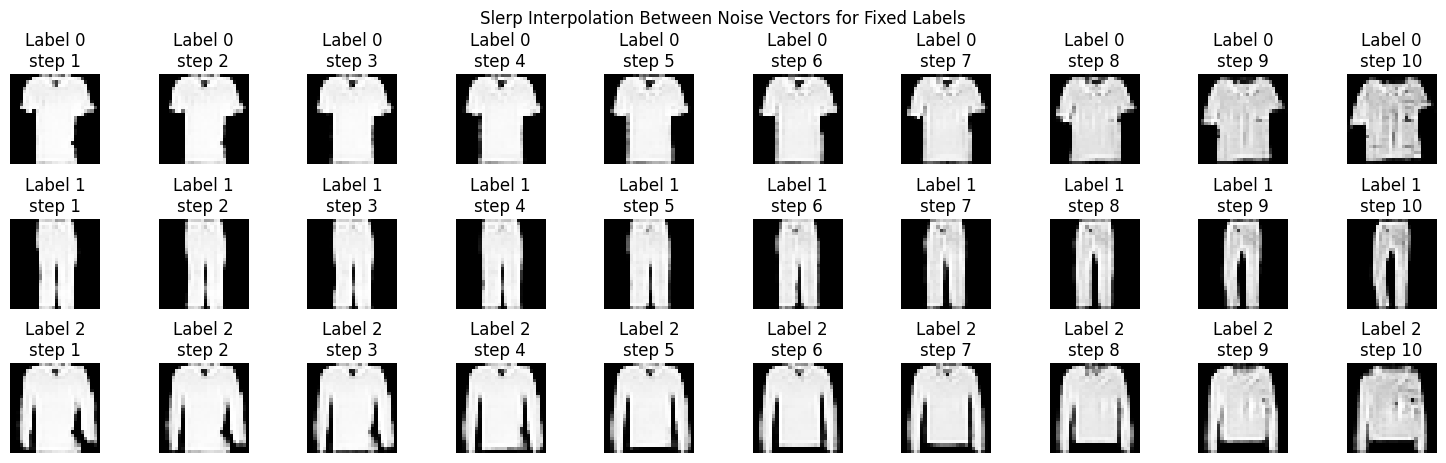

In [ ]:
def slerp(val, low, high):
    # Spherical linear interpolation
    # code from https://github.com/soumith/dcgan.torch/issues/14#issuecomment-199105342
    # Squeeze the 2D tensors to 1D vectors before the dot product
    low_normed = low / torch.norm(low)
    high_normed = high / torch.norm(high)
    omega = torch.acos( low_normed.squeeze(0).dot( high_normed.squeeze(0) ) )
    so = torch.sin(omega)
    return torch.sin((1.0-val)*omega) / so * low + torch.sin(val*omega) / so * high


# Generate two random noise vectors
z1 = torch.randn(1, 100).to(device)
z2 = torch.randn(1, 100).to(device)

# Interpolation steps (10 images)
interpolation_steps = 10
t_values = torch.linspace(0, 1, interpolation_steps)

# Choose 3 different class labels (e.g., 0, 1, 2)
selected_labels = [0, 1, 2]

plt.figure(figsize=(15, len(selected_labels) * 1.5))

G.eval() # Set generator to evaluation mode

for i, label_idx in enumerate(selected_labels):
    interpolated_images = []
    fixed_label = torch.tensor([label_idx]).to(device) # Keep label fixed

    for t in t_values:
        # Perform slerp on noise vectors
        interpolated_z = slerp(t, z1, z2)

        # Generate image from interpolated noise and fixed label
        with torch.no_grad():
            fake_img = G(interpolated_z, fixed_label)
            interpolated_images.append(fake_img.cpu())

    # Display the interpolated images for the current label
    for j, img_tensor in enumerate(interpolated_images):
        ax = plt.subplot(len(selected_labels), interpolation_steps, i * interpolation_steps + j + 1)
        img = (img_tensor * 0.5 + 0.5).squeeze().numpy() # Denormalize and convert to numpy
        ax.imshow(img, cmap='gray')
        ax.set_title(f'Label {label_idx}\nstep {j+1}')
        ax.axis('off')

plt.tight_layout()
plt.suptitle('Slerp Interpolation Between Noise Vectors for Fixed Labels', y=1.02)
plt.show()

### Class Morphing

Now, let's perform class morphing. We'll fix a random noise vector `z` and smoothly interpolate between the embeddings of two different classes. This will reveal how the generator transitions from one class to another while preserving the general characteristics (like pose or style) dictated by the fixed `z`.

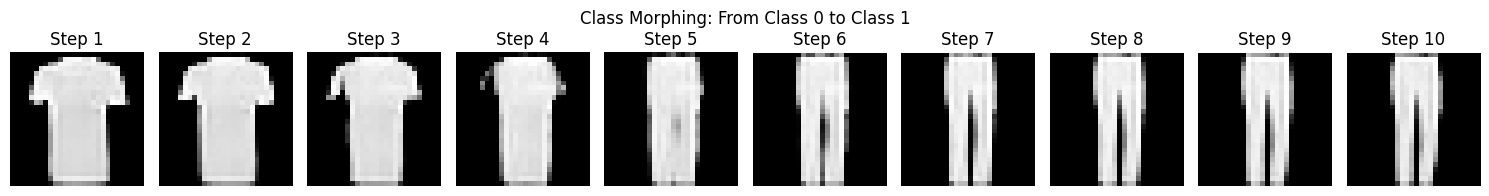

In [ ]:
# Fix a random noise vector z
fixed_z_morph = torch.randn(1, 100).to(device)

# Choose two distinct class labels for morphing (e.g., 0: T-shirt/top, 1: Trouser)
class_A = 0
class_B = 1

# Interpolation steps (10 images)
interpolation_steps = 10
t_values = torch.linspace(0, 1, interpolation_steps)

plt.figure(figsize=(15, 2))

G.eval() # Ensure generator is in evaluation mode

# Generate embeddings for class A and class B
# The Generator's label_emb layer needs a 1-element tensor for the label
label_tensor_A = torch.tensor([class_A], device=device)
label_tensor_B = torch.tensor([class_B], device=device)

embedding_A = G.label_emb(label_tensor_A).squeeze(0) # Get the embedding vector
embedding_B = G.label_emb(label_tensor_B).squeeze(0)

interpolated_images_morph = []

for j, t in enumerate(t_values):
    # Interpolate the class embeddings
    interpolated_embedding = slerp(t, embedding_A, embedding_B)

    # The Generator expects the label embedding to be concatenated with z
    # So, we simulate the 'c' vector from the Generator's forward pass
    # G's fc layer takes (z_dim + num_classes) as input. Here we are replacing num_classes with interpolated embedding.
    # So we need to concatenate z with the interpolated embedding.

    # Note: The original Generator implementation concatenates z with the *output* of label_emb.
    # The label_emb output is num_classes dimensional. So, we'll use our interpolated_embedding directly.
    # The 'c' in G.forward is a num_classes vector from embedding table.

    # We need to construct the input to G's fc layer. This is `torch.cat([z, c], dim=1)` where `c` is from `label_emb(labels)`.
    # Since we are interpolating `c` itself, we can directly use the interpolated_embedding here. This requires adjustment
    # to how the Generator's `fc` layer receives input, or we can ensure `interpolated_embedding` has the correct shape
    # to be treated as `c`.

    # Let's adjust the input to G's fc layer. The original fc takes `z_dim + num_classes`.
    # So we need a `c` vector that is `num_classes` long. `interpolated_embedding` is `num_classes` long.

    # Construct the input to the fc layer manually, maintaining the batch dimension of z
    fc_input = torch.cat([fixed_z_morph, interpolated_embedding.unsqueeze(0)], dim=1)
    x = G.fc(fc_input).view(-1, 256, 4, 4)

    with torch.no_grad():
        fake_img = G.net(x)
        interpolated_images_morph.append(fake_img.cpu())

# Display the interpolated images for class morphing
for j, img_tensor in enumerate(interpolated_images_morph):
    ax = plt.subplot(1, interpolation_steps, j + 1)
    img = (img_tensor * 0.5 + 0.5).squeeze().numpy() # Denormalize and convert to numpy
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Step {j+1}')
    ax.axis('off')

plt.tight_layout()
plt.suptitle(f'Class Morphing: From Class {class_A} to Class {class_B}', y=1.05)
plt.show()

### Discussion on Class Morphing

This class morphing experiment reveals several aspects about the learned class-conditional latent space:

1.  **Smooth Transitions:** If the interpolation produces a visually smooth sequence of images that gradually transform from one class to another (e.g., a T-shirt slowly morphing into a Trouser), it indicates that the class embeddings are meaningfully organized in the latent space, and the generator can interpret intermediate embedding values.

2.  **Disentanglement (to some extent):** A smooth morph suggests a degree of disentanglement between the class information and other features (like pose, texture, or background) controlled by the fixed `z`. The fixed `z` retains its influence on these 'style' attributes, while the changing class embedding primarily drives the category change.

3.  **Semantic Meaning of Latent Space:** The ability to interpolate between classes shows that the class embeddings are not just discrete labels but occupy a continuous, semantically meaningful space. Similar classes might be closer in this embedding space, allowing for gradual transformations.

4.  **Sharp Transitions/Artifacts:** If the transitions are abrupt, or if intermediate images contain many artifacts or unrecognizable forms, it could indicate that the learned class embedding space is not perfectly continuous or that there are regions in the space that the generator struggles to map to coherent images. This might also suggest some level of entanglement.

In essence, successful class morphing demonstrates the generator's capacity to handle and blend different class-conditional information in its generation process, a key feature of conditional GANs.